In [ ]:
from google.colab import files

files.upload()

{}

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
df_ge = pd.read_csv("AAPL.csv")
df_ge.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-06-16,91.510002,92.750000,91.449997,92.199997,84.503571,35561000
1,2014-06-17,92.309998,92.699997,91.800003,92.080002,84.393570,29726000
2,2014-06-18,92.269997,92.290001,91.349998,92.180000,84.485222,33514000
3,2014-06-19,92.290001,92.300003,91.339996,91.860001,84.191948,35528000
4,2014-06-20,91.849998,92.550003,90.900002,90.910004,83.321236,100898000


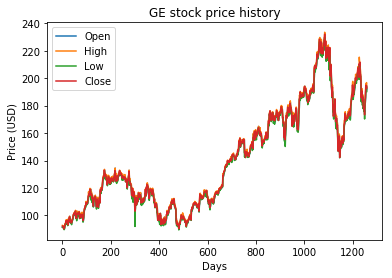

In [ ]:
plt.figure()
plt.plot(df_ge["Open"])
plt.plot(df_ge["High"])
plt.plot(df_ge["Low"])
plt.plot(df_ge["Close"])
plt.title('GE stock price history')
plt.ylabel('Price (USD)')
plt.xlabel('Days')
plt.legend(['Open','High','Low','Close'], loc='upper left')
plt.show()

In [ ]:
#PREPREOCESSING

print("checking if any null values are present\n", df_ge.isna().sum())

checking if any null values are present
 Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

train_cols = ["Open","High","Low","Close","Volume"]
df_train, df_test = train_test_split(df_ge, train_size=0.8, test_size=0.2, shuffle=False)
print("Train and Test size", len(df_train), len(df_test))
# scale the feature MinMax, build array
x = df_train.loc[:,train_cols].values
min_max_scaler = MinMaxScaler()
x_train = min_max_scaler.fit_transform(x)
x_test = min_max_scaler.transform(df_test.loc[:,train_cols])

Train and Test size 1007 252


In [ ]:
def build_timeseries(mat, y_col_index):
    # y_col_index is the index of column that would act as output column
    # total number of time-series samples would be len(mat) - TIME_STEPS
    dim_0 = mat.shape[0] - TIME_STEPS
    dim_1 = mat.shape[1]
    x = np.zeros((dim_0, TIME_STEPS, dim_1))
    y = np.zeros((dim_0,))

    for i in range(dim_0):
        x[i] = mat[i:TIME_STEPS+i]
        y[i] = mat[TIME_STEPS+i, y_col_index]
    print("length of time-series i/o",x.shape,y.shape)
    return x, y

In [ ]:
def trim_dataset(mat, batch_size):
    """
    trims dataset to a size that's divisible by BATCH_SIZE
    """
    no_of_rows_drop = mat.shape[0]%batch_size
    if(no_of_rows_drop > 0):
        return mat[:-no_of_rows_drop]
    else:
        return mat

In [ ]:
BATCH_SIZE = 20
TIME_STEPS = 60

x_t, y_t = build_timeseries(x_train, 3)
x_t = trim_dataset(x_t, BATCH_SIZE)
y_t = trim_dataset(y_t, BATCH_SIZE)
x_temp, y_temp = build_timeseries(x_test, 3)
x_val, x_test_t = np.split(trim_dataset(x_temp, BATCH_SIZE),2)
y_val, y_test_t = np.split(trim_dataset(y_temp, BATCH_SIZE),2)

length of time-series i/o (947, 60, 5) (947,)
length of time-series i/o (192, 60, 5) (192,)


In [ ]:
import pickle
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout
from keras.layers import LSTM
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from keras import optimizers
# from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import logging

Using TensorFlow backend.


In [ ]:
lstm_model = Sequential()
lstm_model.add(LSTM(100, batch_input_shape=(BATCH_SIZE, TIME_STEPS, x_t.shape[2]), dropout=0.0, recurrent_dropout=0.0, stateful=True,     kernel_initializer='random_uniform'))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(20,activation='relu'))
lstm_model.add(Dense(1,activation='sigmoid'))
optimizer = optimizers.RMSprop(lr=0.0001)
lstm_model.compile(loss='mean_squared_error', optimizer=optimizer)

W0616 08:41:56.679399 140120524654464 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:74: The name tf.get_default_graph is deprecated. Please use tf.compat.v1.get_default_graph instead.

W0616 08:41:56.733165 140120524654464 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:517: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.

W0616 08:41:56.742842 140120524654464 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:4138: The name tf.random_uniform is deprecated. Please use tf.random.uniform instead.

W0616 08:41:56.983440 140120524654464 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:133: The name tf.placeholder_with_default is deprecated. Please use tf.compat.v1.placeholder_with_default instead.

W0616 08:41:56.991388 

In [ ]:

csv_logger = CSVLogger('your_log_name' + '.log', append=True)

history = lstm_model.fit(x_t, y_t, epochs=300, verbose=2, batch_size=BATCH_SIZE,
                    shuffle=False, validation_data=(trim_dataset(x_val, BATCH_SIZE),
                    trim_dataset(y_val, BATCH_SIZE)), callbacks=[csv_logger])

W0616 08:41:57.244236 140120524654464 deprecation.py:323] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/math_grad.py:1250: add_dispatch_support.<locals>.wrapper (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
W0616 08:41:57.538154 140120524654464 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:986: The name tf.assign_add is deprecated. Please use tf.compat.v1.assign_add instead.



Train on 940 samples, validate on 80 samples
Epoch 1/300
 - 7s - loss: 0.0781 - val_loss: 0.3371
Epoch 2/300
 - 3s - loss: 0.0760 - val_loss: 0.3120
Epoch 3/300
 - 3s - loss: 0.0741 - val_loss: 0.2837
Epoch 4/300
 - 3s - loss: 0.0710 - val_loss: 0.2407
Epoch 5/300
 - 3s - loss: 0.0662 - val_loss: 0.1793
Epoch 6/300
 - 3s - loss: 0.0568 - val_loss: 0.0986
Epoch 7/300
 - 3s - loss: 0.0288 - val_loss: 0.0841
Epoch 8/300
 - 3s - loss: 0.0199 - val_loss: 0.0828
Epoch 9/300
 - 3s - loss: 0.0176 - val_loss: 0.0833
Epoch 10/300
 - 3s - loss: 0.0167 - val_loss: 0.0826
Epoch 11/300
 - 3s - loss: 0.0154 - val_loss: 0.0815
Epoch 12/300
 - 3s - loss: 0.0149 - val_loss: 0.0820
Epoch 13/300
 - 3s - loss: 0.0139 - val_loss: 0.0805
Epoch 14/300
 - 3s - loss: 0.0131 - val_loss: 0.0781
Epoch 15/300
 - 3s - loss: 0.0115 - val_loss: 0.0778
Epoch 16/300
 - 3s - loss: 0.0115 - val_loss: 0.0767
Epoch 17/300
 - 3s - loss: 0.0109 - val_loss: 0.0744
Epoch 18/300
 - 3s - loss: 0.0112 - val_loss: 0.0734
Epoch 19/3

In [ ]:
lstm_model.save("m.h5")

from google.colab import files

files.download("m.h5")

In [ ]:
# prediction on test set

y_pred = lstm_model.predict(trim_dataset(x_test_t, BATCH_SIZE), batch_size=BATCH_SIZE)
y_pred = y_pred.flatten()
y_test_t = trim_dataset(y_test_t, BATCH_SIZE)
error = mean_squared_error(y_test_t, y_pred)
print("Error is", error, y_pred.shape, y_test_t.shape)
print(y_pred[0:15])
print(y_test_t[0:15])
y_pred_org = (y_pred * min_max_scaler.data_range_[3]) + min_max_scaler.data_min_[3] # min_max_scaler.inverse_transform(y_pred)
y_test_t_org = (y_test_t * min_max_scaler.data_range_[3]) + min_max_scaler.data_min_[3] # min_max_scaler.inverse_transform(y_test_t)
print(y_pred_org[0:15])
print(y_test_t_org[0:15])

Error is 0.01099949858367626 (80,) (80,)
[0.57053405 0.5853631  0.59560657 0.6040344  0.60982966 0.6194422
 0.6270385  0.6313543  0.6470402  0.6679936  0.68813086 0.70722556
 0.72728676 0.7444743  0.7547752 ]
[0.64165873 0.60771462 0.61369335 0.60192864 0.65072322 0.63664422
 0.62102214 0.72295085 0.73442628 0.73519776 0.78081006 0.80906457
 0.80964328 0.77782069 0.77270981]
[149.44438 150.98215 152.0444  152.91837 153.51933 154.51616 155.3039
 155.75143 157.37807 159.55093 161.63916 163.6193  165.69963 167.48198
 168.55019]
[156.820007 153.300003 153.919998 152.699997 157.759995 156.300003
 154.679993 165.25     166.440002 166.520004 171.25     174.179993
 174.240005 170.940002 170.410004]


In [ ]:
#predication on whole dataset

import numpy as np
x_main = np.concatenate((x_t,x_test_t),axis=0)
y_main = np.concatenate((y_t,y_test_t),axis=0)

y_pred = lstm_model.predict(trim_dataset(x_main, BATCH_SIZE), batch_size=BATCH_SIZE)
y_pred = y_pred.flatten()
y_test_t = trim_dataset(y_main, BATCH_SIZE)
error = mean_squared_error(y_test_t, y_pred)

print("Error is", error, y_pred.shape, y_test_t.shape)
print(y_pred[0:15])
print(y_test_t[0:15])
y_pred_org = (y_pred * min_max_scaler.data_range_[3]) + min_max_scaler.data_min_[3] # min_max_scaler.inverse_transform(y_pred)
y_test_t_org = (y_test_t * min_max_scaler.data_range_[3]) + min_max_scaler.data_min_[3] # min_max_scaler.inverse_transform(y_test_t)
print(y_pred_org[0:15])
print(y_test_t_org[0:15])

Error is 0.002837918593398847 (1020,) (1020,)
[0.12801296 0.12227711 0.1207121  0.1203405  0.12134263 0.12058634
 0.12161228 0.12526283 0.12621695 0.12858602 0.13040501 0.13266009
 0.1287038  0.12788805 0.12740687]
[0.10337513 0.10752171 0.10973968 0.10945032 0.10202509 0.10896821
 0.11099327 0.1029894  0.10395371 0.11918997 0.11060753 0.07319194
 0.10096433 0.09479269 0.10096433]
[103.55494  102.96014  102.797844 102.75931  102.86323  102.784805
 102.89119  103.26975  103.3687   103.61437  103.80299  104.03685
 103.62659  103.54199  103.49209 ]
[101.       101.43     101.660004 101.629997 100.860001 101.580002
 101.790001 100.959999 101.059998 102.639999 101.75      97.870003
 100.75     100.110001 100.75    ]


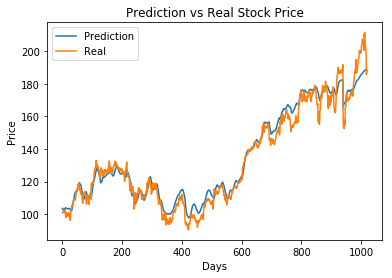

In [ ]:
from matplotlib import pyplot as plt
plt.figure()
plt.plot(y_pred_org)
plt.plot(y_test_t_org)
plt.title('Prediction vs Real Stock Price')
plt.ylabel('Price')
plt.xlabel('Days')
plt.legend(['Prediction', 'Real'], loc='upper left')
plt.show()
